In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt


files = {
    "native": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/nativebla3/results.csv",
    "sev": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/sevbla2/results.csv",
}
iter = {
    "n1": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/base1/iter.csv",
    "n2": "/home/mengelsl/MA-bench-framework/outputs/spmv/v2/base2/iter.csv",
}
#CSV format:
all_data = []
for name, path in files.items():
    df = pd.read_csv(path)
    df['Environment'] = name 
    all_data.append(df)
df = pd.concat(all_data, ignore_index=True)

all_data = []
for name, path in iter.items():
    df_iter = pd.read_csv(path)
    df_iter['Environment'] = name 
    all_data.append(df_iter)
df_iter = pd.concat(all_data, ignore_index=True)


In [21]:
df

,Matrix,Cores,Run,Iterations,IO_Time,SpMV_Time,SpMV_GFLOPS,Perf_Cycles,Perf_Instructions,Perf_CacheMisses,Perf_dTLBMisses,Voluntary_CtxSwitches,Involuntary_CtxSwitches,Environment
0,0-0_N1008246.bin,8.000000,1.00000,500.00000,7.488220e-02,5.207060e+00,5.808920e+00,96685089584,189634382984,8641587,4979,7,372,z1
1,0-0_N1008246.bin,8.000000,2.00000,500.00000,6.561540e-02,5.202680e+00,5.813810e+00,96702065352,189622923898,8677301,5379,5,254,z1
2,0-0_N1008246.bin,8.000000,3.00000,500.00000,6.540880e-02,5.199670e+00,5.817180e+00,96681591471,189621877265,8672823,5402,0,202,z1
3,0-0_N1008246.bin,8.000000,4.00000,500.00000,6.546260e-02,5.200790e+00,5.815920e+00,96704528045,189618960300,8697093,4346,0,163,z1
4,0-0_N1008246.bin,8.000000,5.00000,500.00000,6.536090e-02,5.201240e+00,5.815420e+00,96734548937,189622136764,8656800,4374,5,129,z1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
160,500,0.066638,5.20104,5.81564,9.677441e+10,1.891165e+11,8.958802e+06,7655,4,40,16,16,16,z5
161,500,0.066524,5.20008,5.81671,9.669116e+10,1.891252e+11,9.012039e+06,8140,3,72,16,16,16,z5
162,500,0.066540,5.19977,5.81707,9.674919e+10,1.891126e+11,8.974169e+06,8201,4,44,16,16,16,z5
163,500,0.066584,5.19665,5.82056,9.669036e+10,1.891130e+11,8.952882e+06,6083,4,66,16,16,16,z5


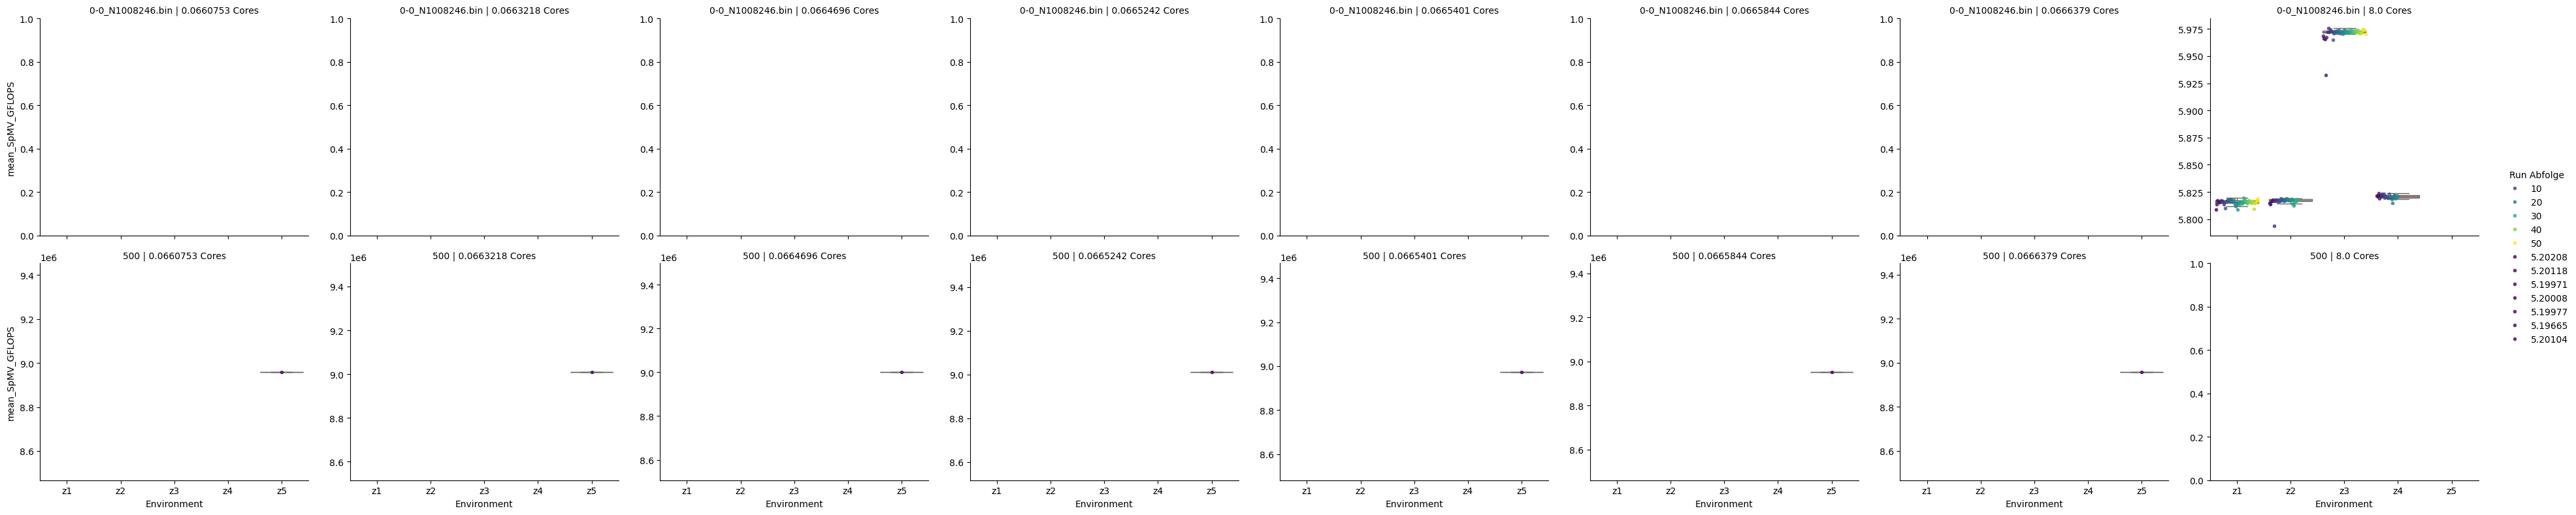

In [20]:
run_means_detailed = (
    df
    .groupby(['Matrix', 'Cores', 'Environment', 'Run'])['SpMV_GFLOPS']
    .mean()
    .reset_index(name='mean_SpMV_GFLOPS')
    .sort_values('Run')
)

g = sns.catplot(
    data=run_means_detailed, 
    x='Environment', 
    y='mean_SpMV_GFLOPS', 
    col='Cores', 
    row='Matrix', 
    kind='box',         
    showfliers=False,
    hue='Environment',          
    palette='Set3',
    height=4, 
    aspect=1.2,
    sharey=False,
    legend=False            
)

# 3. Den Swarmplot drüberlegen mit sequentieller Palette für 'Run'
# 'viridis' geht von Violett (Anfang) über Blau/Grün nach Gelb (Ende)
g.map_dataframe(
    sns.swarmplot, 
    x='Environment', 
    y='mean_SpMV_GFLOPS', 
    hue='Run', 
    palette='viridis', # Sequentielle Palette zeigt die Abfolge
    dodge=True,        # Trennt die Runs leicht auf, falls sie sich überlagern
    size=4,            # Punktgröße etwas kleiner für bessere Übersicht
    alpha=0.8          # Leicht transparent, damit man Überlagerungen sieht
)

# 4. Legende für die Runs hinzufügen (da catplot die Legende für map_dataframe oft nicht automatisch baut)
g.add_legend(title="Run Abfolge", adjust_subtitles=True)

# Optional: Titel der Facetten schöner machen
g.set_titles("{row_name} | {col_name} Cores")

plt.show()

<Axes: xlabel='Perf_dTLBMisses', ylabel='Environment'>

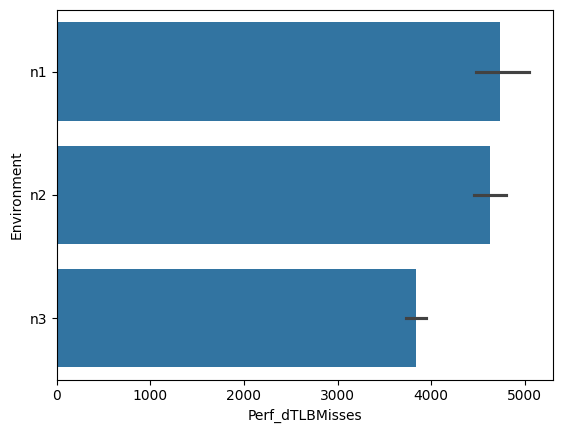

In [133]:
sns.barplot(data=df, x= 'Perf_dTLBMisses', y='Environment')